# Task 3 – Domain generalization (Sketch unseen)
Run **after** the Task 2 notebook. Uses Task 2's split file and `source_only.pt` from `PA1_v2` on Drive.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Upload pa1_code.zip to the root of "My Drive" first.
!rm -rf /content/pa1 && unzip -q -o /content/drive/MyDrive/pa1_code.zip -d /content/
DRIVE = "/content/drive/MyDrive/PA1_v2"      # all new results go here (separate from old runs)
!mkdir -p {DRIVE}
!mkdir -p {DRIVE}/task3_results
!rm -rf /content/pa1/task3/results /content/pa1/task2/results /content/pa1/shared/splits
!ln -s {DRIVE}/task3_results /content/pa1/task3/results
!ln -s {DRIVE}/task2_results /content/pa1/task2/results     # ERM checkpoint + Task 2 report (read only)
!ln -s {DRIVE}/shared_splits /content/pa1/shared/splits      # the SAME split file as Task 2
!ls -la /content/pa1/shared/splits/ /content/pa1/task2/results/checkpoints/source_only.pt
%cd /content/pa1/task3

Mounted at /content/drive
-rw------- 1 root root 44797323 Sep 25 00:53 /content/pa1/task2/results/checkpoints/source_only.pt

/content/pa1/shared/splits/:
total 498
drwx------ 2 root root   4096 Sep 25 00:47 .
drwx------ 5 root root   4096 Sep 25 03:16 ..
-rw------- 1 root root 500743 Sep 25 00:48 pacs_sketch_seed6304.json
/content/pa1/task3


In [2]:
import torch
print("CUDA:", torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")

CUDA: True Tesla T4


## 1. PACS – the same download as Task 2 (the split fingerprint is checked)

In [3]:
!python ../shared/download_pacs.py --out /content/pacs_data

Cloning https://github.com/MachineLearning2020/Homework3-PACS.git ...
PACS moved to /content/pacs_data
  [OK ] photo         total= 1670 per class=[189, 202, 182, 186, 199, 280, 432]
  [OK ] art_painting  total= 2048 per class=[379, 255, 285, 184, 201, 295, 449]
  [OK ] cartoon       total= 2344 per class=[389, 457, 346, 135, 324, 288, 405]
  [OK ] sketch        total= 3929 per class=[772, 740, 753, 608, 816, 80, 160]
All 4 domains x 7 classes verified (9,991 images).


## 2. Train DAN-DG and SAM (no Sketch data is loaded)

In [4]:
!python train.py --config configs/dan_dg.yaml

[dan_dg] device=cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100% 44.7M/44.7M [00:00<00:00, 192MB/s]
[dan_dg] epoch 0: mean source-val macro-F1=0.9084 {'photo': 0.943, 'art_painting': 0.864, 'cartoon': 0.918} | loss=0.5797 cls_loss=0.5038 mean_pairwise_mmd=0.0760
[dan_dg] epoch 1: mean source-val macro-F1=0.9278 {'photo': 0.958, 'art_painting': 0.886, 'cartoon': 0.939} | loss=0.2625 cls_loss=0.2277 mean_pairwise_mmd=0.0348
[dan_dg] epoch 2: mean source-val macro-F1=0.9050 {'photo': 0.932, 'art_painting': 0.861, 'cartoon': 0.922} | loss=0.1951 cls_loss=0.1678 mean_pairwise_mmd=0.0273
[dan_dg] epoch 3: mean source-val macro-F1=0.9285 {'photo': 0.954, 'art_painting': 0.905, 'cartoon': 0.926} | loss=0.1395 cls_loss=0.1083 mean_pairwise_mmd=0.0312
[dan_dg] epoch 4: mean source-val macro-F1=0.9189 {'photo': 0.943, 'art_painting': 0.887, 'cartoon': 0.927} | loss=0.1350 cls_loss=0.1084 mean_pairwise_mm

In [5]:
!python train.py --config configs/sam.yaml

[sam] device=cuda
[sam] epoch 0: mean source-val macro-F1=0.8789 {'photo': 0.926, 'art_painting': 0.823, 'cartoon': 0.887} | loss=0.9697 cls_loss=0.9697 loss_at_perturbed_point=1.2575
[sam] epoch 1: mean source-val macro-F1=0.9062 {'photo': 0.928, 'art_painting': 0.866, 'cartoon': 0.925} | loss=0.2801 cls_loss=0.2801 loss_at_perturbed_point=0.5399
[sam] epoch 2: mean source-val macro-F1=0.9466 {'photo': 0.957, 'art_painting': 0.924, 'cartoon': 0.959} | loss=0.1867 cls_loss=0.1867 loss_at_perturbed_point=0.4045
[sam] epoch 3: mean source-val macro-F1=0.9434 {'photo': 0.95, 'art_painting': 0.924, 'cartoon': 0.955} | loss=0.1220 cls_loss=0.1220 loss_at_perturbed_point=0.3087
[sam] epoch 4: mean source-val macro-F1=0.9377 {'photo': 0.966, 'art_painting': 0.903, 'cartoon': 0.943} | loss=0.0846 cls_loss=0.0846 loss_at_perturbed_point=0.2501
[sam] epoch 5: mean source-val macro-F1=0.9511 {'photo': 0.961, 'art_painting': 0.929, 'cartoon': 0.963} | loss=0.0600 cls_loss=0.0600 loss_at_perturbed_

## 3. Controlled study: λ_DG ∈ {0.1, 1, 10} (λ = 1 reuses the main DAN-DG checkpoint)

In [6]:
!python run_controlled_study.py --study dan_dg

--- lambda_dg=0.1: training
[dan_dg_lambda_dg0.1] device=cuda
[dan_dg_lambda_dg0.1] epoch 0: mean source-val macro-F1=0.8951 {'photo': 0.927, 'art_painting': 0.841, 'cartoon': 0.918} | loss=0.4969 cls_loss=0.4813 mean_pairwise_mmd=0.1562
[dan_dg_lambda_dg0.1] epoch 1: mean source-val macro-F1=0.8810 {'photo': 0.918, 'art_painting': 0.872, 'cartoon': 0.854} | loss=0.2259 cls_loss=0.2176 mean_pairwise_mmd=0.0822
[dan_dg_lambda_dg0.1] epoch 2: mean source-val macro-F1=0.9210 {'photo': 0.945, 'art_painting': 0.883, 'cartoon': 0.935} | loss=0.1494 cls_loss=0.1433 mean_pairwise_mmd=0.0615
[dan_dg_lambda_dg0.1] epoch 3: mean source-val macro-F1=0.9298 {'photo': 0.961, 'art_painting': 0.896, 'cartoon': 0.932} | loss=0.1088 cls_loss=0.1028 mean_pairwise_mmd=0.0592
[dan_dg_lambda_dg0.1] epoch 4: mean source-val macro-F1=0.9286 {'photo': 0.936, 'art_painting': 0.912, 'cartoon': 0.938} | loss=0.1058 cls_loss=0.1008 mean_pairwise_mmd=0.0503
[dan_dg_lambda_dg0.1] epoch 5: mean source-val macro-F1=0.

## 4. Final evaluation – the only step that loads Sketch
It first checks that ERM (Task 2 `source_only.pt`) and the split match, and that ERM reproduces Task 2's numbers.

In [7]:
!python evaluate_sketch.py --controlled_study dan_dg

ERM checkpoint and split fingerprints match (same data as Task 2).
Evaluated dan_dg.
Evaluated sam.
ERM vs Task 2 Source-only identical: True

Comparison table:
{'method': 'erm', 'photo_val_acc': 0.964, 'art_painting_val_acc': 0.9415, 'cartoon_val_acc': 0.9424, 'photo_val_f1': 0.9581, 'art_painting_val_f1': 0.9421, 'cartoon_val_f1': 0.9466, 'mean_source_acc': 0.9493, 'mean_source_f1': 0.9489, 'worst_source_acc': 0.9415, 'worst_source_domain': 'art_painting', 'worst_source_f1': 0.9421, 'sketch_acc': 0.5729, 'sketch_f1': 0.584, 'sketch_acc_change_vs_erm': 0.0, 'source_domain_separability': 0.86, 'sharpness_delta': 0.318178, 'best_epoch': 6}
{'method': 'dan_dg', 'photo_val_acc': 0.967, 'art_painting_val_acc': 0.8976, 'cartoon_val_acc': 0.9403, 'photo_val_f1': 0.9605, 'art_painting_val_f1': 0.8947, 'cartoon_val_f1': 0.9437, 'mean_source_acc': 0.9349, 'mean_source_f1': 0.9329, 'worst_source_acc': 0.8976, 'worst_source_domain': 'art_painting', 'worst_source_f1': 0.8947, 'sketch_acc': 0.5775,

Accuracies / F1 / separability in %; sharpness = raw CE increase.

| method | photo_val_acc | art_painting_val_acc | cartoon_val_acc | mean_source_acc | mean_source_f1 | worst_source_acc | sketch_acc | sketch_f1 | sketch_acc_change_vs_erm | source_domain_separability | sharpness_delta |
|---|---|---|---|---|---|---|---|---|---|---|---|
| erm | 96.40 | 94.15 | 94.24 | 94.93 | 94.89 | 94.15 | 57.29 | 58.40 | 0.00 | 86.00 | 0.3182 |
| dan_dg | 96.70 | 89.76 | 94.03 | 93.49 | 93.29 | 89.76 | 57.75 | 57.66 | 0.46 | 68.67 | 0.3467 |
| sam | 98.20 | 92.68 | 96.16 | 95.68 | 95.76 | 92.68 | 68.31 | 67.45 | 11.02 | 87.67 | 0.1353 |

ERM matches Task 2: {'task2_source_only_target_acc': 0.5729, 'task3_erm_sketch_acc': 0.5729, 'photo_val_acc': {'task2': 0.964, 'task3': 0.964}, 'art_painting_val_acc': {'task2': 0.9415, 'task3': 0.9415}, 'cartoon_val_acc': {'task2': 0.9424, 'task3': 0.9424}, 'identical': True}
results/plots/controlled_study_dan_dg.png


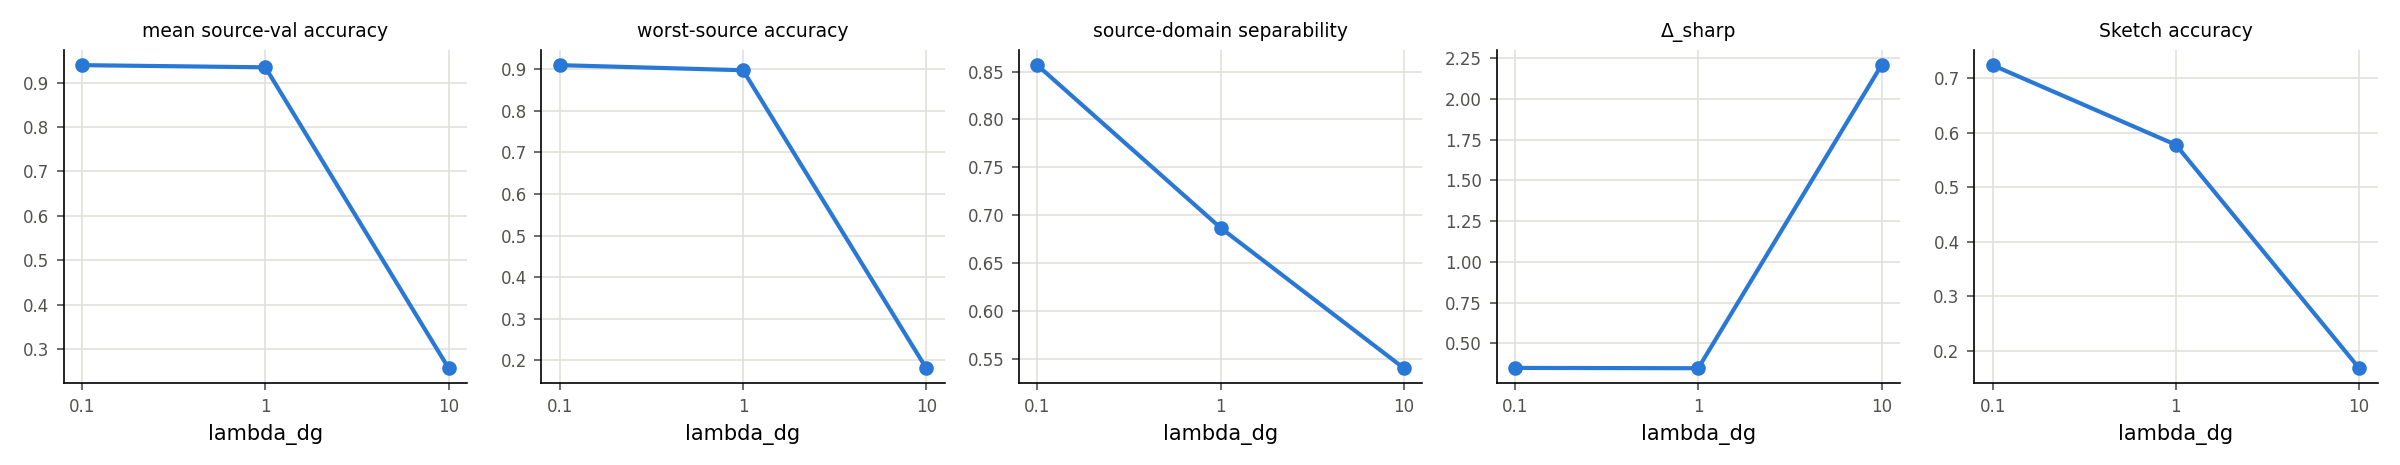

results/plots/controlled_study_dan_dg_curves.png


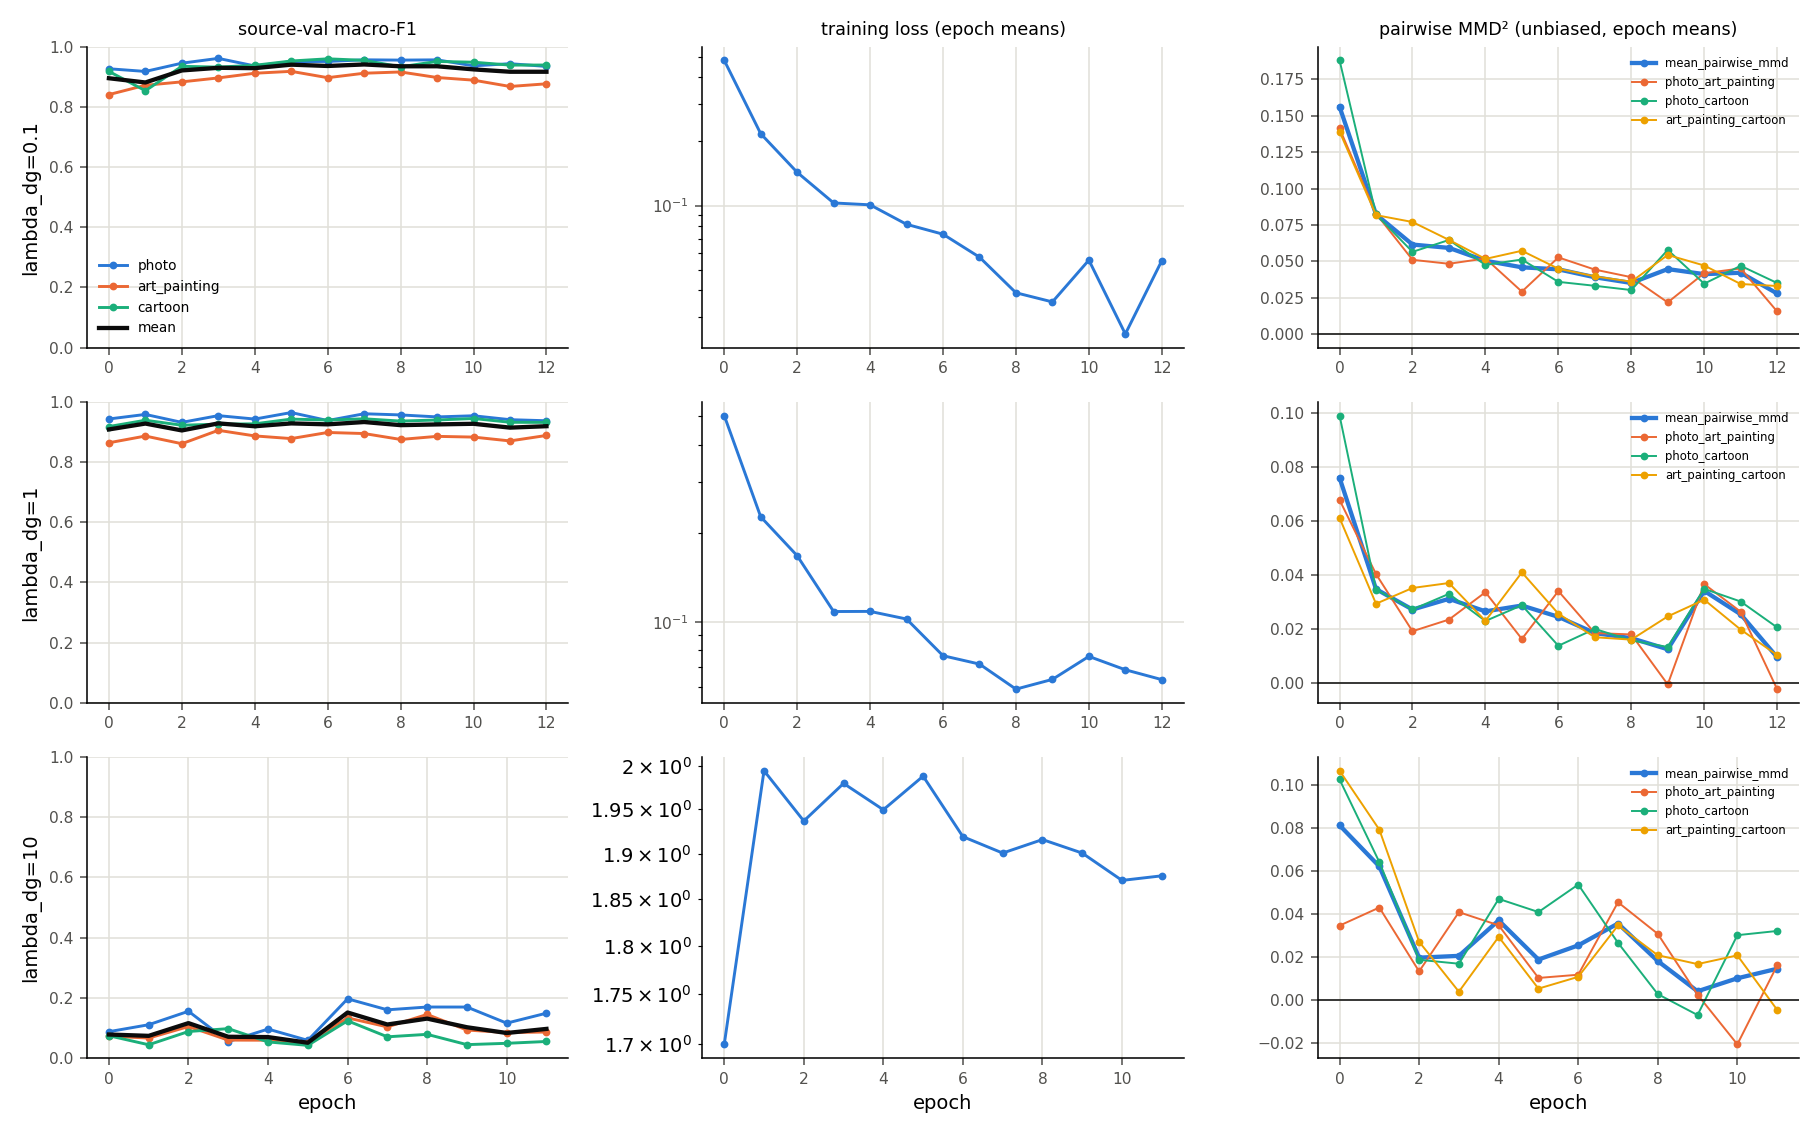

results/plots/per_class_sketch_delta.png


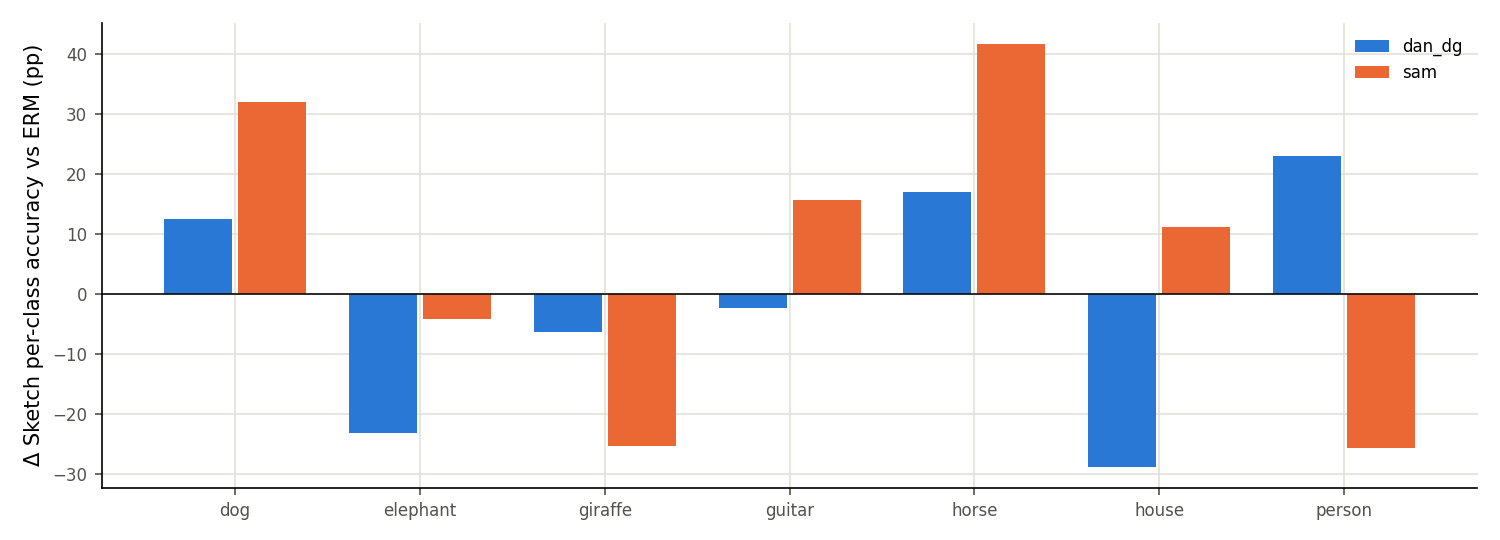

results/plots/sketch_confusions.png


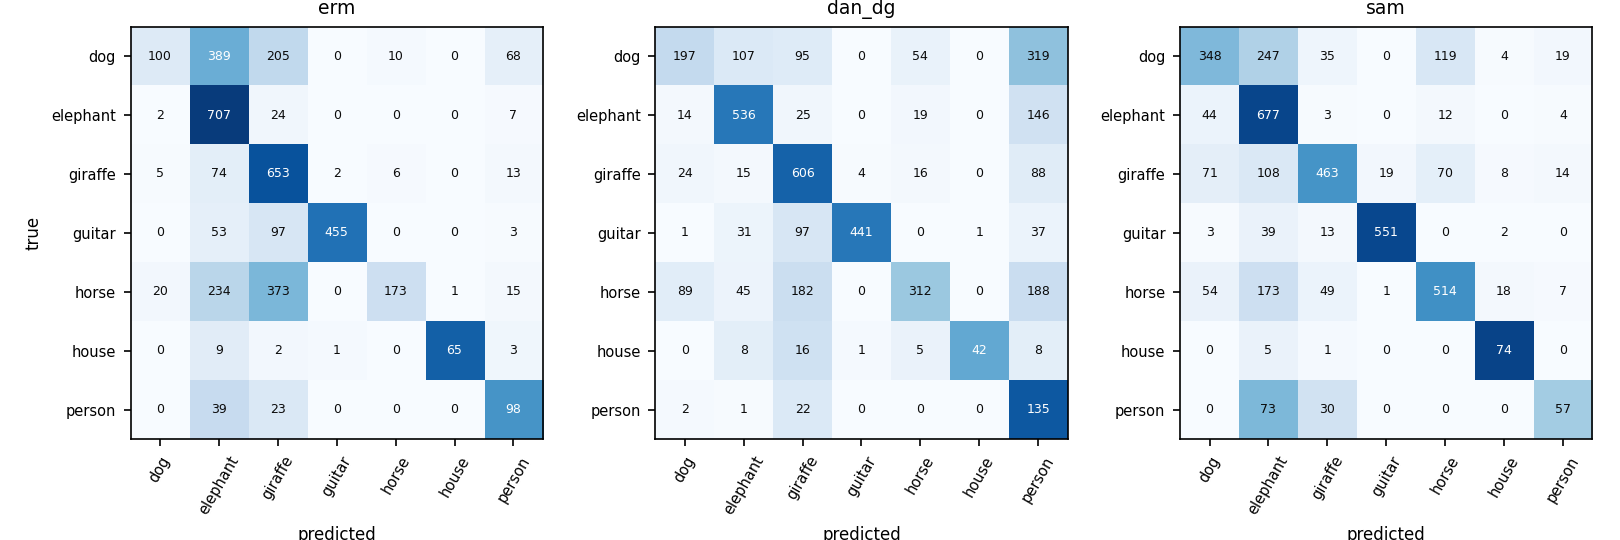

results/plots/training_curves.png


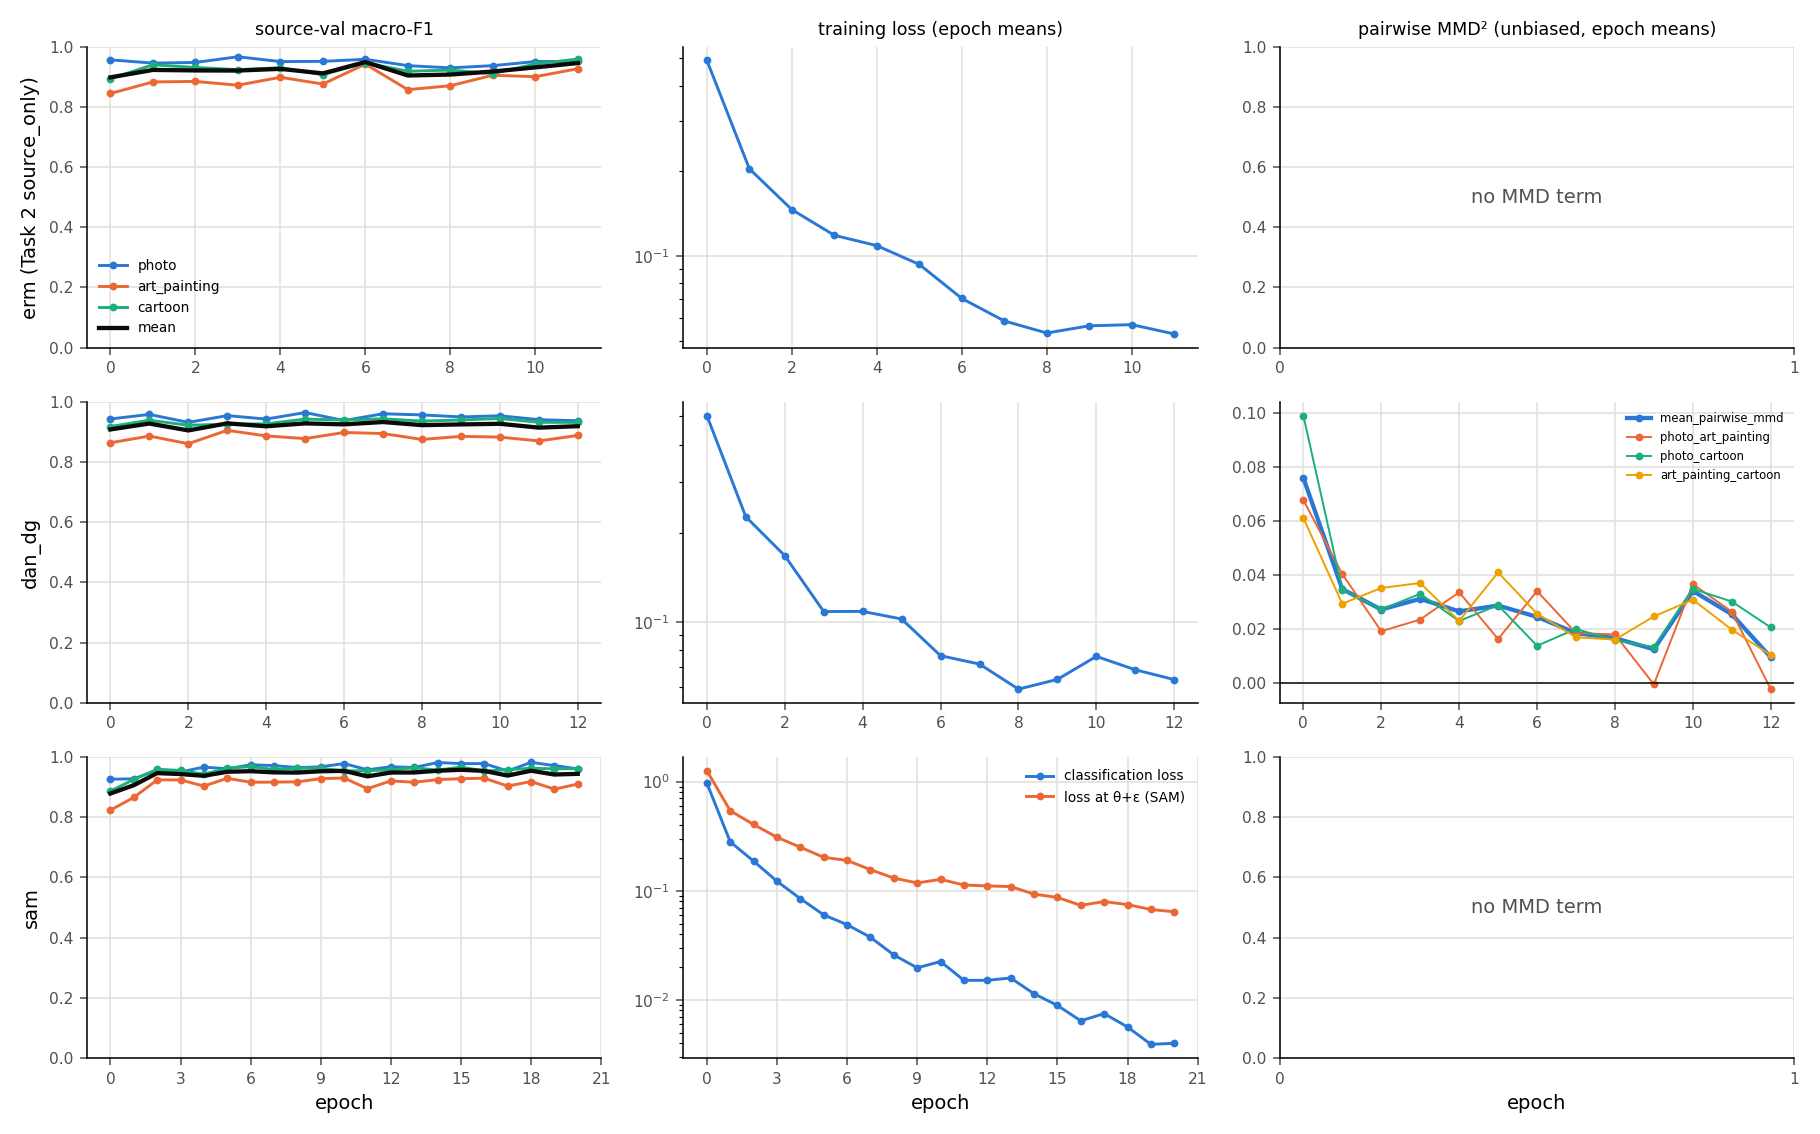

In [8]:
import glob, json
from IPython.display import Image, display
print(open('results/comparison_table.md').read())
r = json.load(open('results/final_report.json'))
print('ERM matches Task 2:', r['erm_matches_task2'])
for f in sorted(glob.glob('results/plots/*.png')):
    print(f); display(Image(f, width=1100))

Results are already on Drive in `PA1_v2/task3_results`.